# Analyze ProT dataset
Data used in this notebook:
- Benign reference: The benign reference dataset used in this notebook comprises the HLA Ligand Atlas Lumos and HLA Ligand Atlas timsTOF.
- Malignant data: The immunopeptidomes of prostate tissue.

The resulting vaccine is directed against prostate tissue. It is not distinguished between malignant and benign tissue. 

In [ ]:
import pandas as pd
import subprocess
import sys
import ast
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import numpy as np
from matplotlib import colors
sys.path.append('../functions')
from peptide_annotator import get_peptide_lengths, proteome_to_dict, create_fasta_dict, annotate_peptides, add_positions
from data_inspection import length_distribution

## Prepare data for epicore

In [ ]:
# read in malignant data
info_df = pd.read_excel('Sample_Overview.xlsx')

# class 1
malignant1_df = pd.read_csv('/mnt/volume/jana/data/ProT_quant_class1_combined.tsv', sep='\t')
malignant1_df = pd.merge(malignant1_df, info_df[['Specimen ID','Dignity','HLA Typing']], left_on='sample', right_on='Specimen ID', how='left')
malignant1_df = malignant1_df.drop(columns='Specimen ID')
print(f'Removed the following samples of class1 due to missing dignity information:{set(malignant1_df[malignant1_df["Dignity"].isnull()]["sample"].value_counts().keys())}')
malignant1_df = malignant1_df[~malignant1_df['Dignity'].isnull()]
malignant1_df['mhc_class'] = 'I'

# class 2
malignant2_df = pd.read_csv('/mnt/volume/jana/data/ProT_quant_class2_combined.tsv', sep='\t')
malignant2_df = pd.merge(malignant2_df, info_df[['Specimen ID','Dignity','HLA Typing']], left_on='sample', right_on='Specimen ID', how='left')
malignant2_df = malignant2_df.drop(columns='Specimen ID')
print(f'Removed the following samples of class2 due to missing dignity information:{set(malignant2_df[malignant2_df["Dignity"].isnull()]["sample"].value_counts().keys())}')
malignant2_df = malignant2_df[~malignant2_df['Dignity'].isnull()]
malignant2_df['mhc_class'] = 'II' 

malignant_df = pd.concat([malignant1_df, malignant2_df])
malignant_df = malignant_df.rename(columns={'Dignity':'dignity', 'HLA Typing':'condition'})

In [9]:
# read in benign data
benign_df = pd.read_csv('/mnt/volume/jana/thesis/data/newbenign/benign_HLA_Ligand_Atlas_Lumos_timsTOF.tsv',sep='\t')[['peptide_sequence','mhc_class','dignity','donor_code','all_hla_alleles_donor','biological_material_name','qbic_project_code']]
benign_df = benign_df.rename(columns={'peptide_sequence':'sequence','donor_code':'sample','all_hla_alleles_donor':'condition'})
benign_df = benign_df.drop_duplicates(['sequence','mhc_class','dignity','sample','condition'])
benign_df['sample'] = benign_df['sample'] + '_' + benign_df['biological_material_name']
benign_df['condition'] = benign_df['condition'].fillna('XXX')

In [57]:
# combine data
combined_df = pd.concat([benign_df, malignant_df])
combined_df = combined_df[['sequence','sample','condition', 'mhc_class']]
combined_df['condition'] = combined_df['condition'].apply(lambda cell: cell.replace(';','~'))

In [ ]:
# annotate data
lengths = get_peptide_lengths(combined_df)
proteome_dict = proteome_to_dict('/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta')
fasta_dict = create_fasta_dict(proteome_dict, lengths)
combined_df = annotate_peptides(fasta_dict, combined_df)
combined_df = add_positions(proteome_dict, combined_df,'accessions','sequence')
combined_df['condition'] = 'one'
class1_df = combined_df[combined_df['mhc_class']=='I']
class2_df = combined_df[combined_df['mhc_class']=='II']
class2_df.to_csv('class2_peptides.csv')
class1_df.to_csv('class1_peptides.csv')

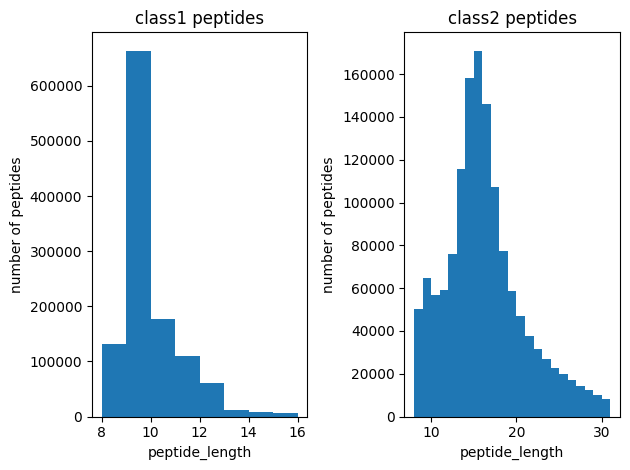

In [ ]:
# visualize length distribution
class1_df = class1_df[class1_df['accessions']!='unmapped']
class2_df = class2_df[class2_df['accessions']!='unmapped']
length_distribution(class1_df[['sequence','accessions','start','end']],class2_df[['sequence','accessions','start','end']])

## Run epicore

In [ ]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class2_included', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class2_included', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

In [ ]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class2_strict', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class2_strict', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [ ]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class1_included', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class1_included', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

In [ ]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class1_strict', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/data/B_spHUMANwiso_230830.fasta', '--out_dir', 'Class1_strict', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

## Analyze the peptide groups with available immunogenicity data

In [ ]:
def compute_frequencies(epitopes_csv, peptides_csv, allotype, typing_dict, info_dict):
    '''Compute frequencies on peptide and peptide group levbel.

    Args:
        epitopes_csv: Path to csv containing peptide groups.
        peptides_csv: Path to csv containing peptides.
        allotype: The allotype of interest.

    Returns:
        A dataframe containing the frequencies of the peptide groups and their peptides.
    '''

    # compute peptide frequencies
    peptides_df = pd.read_csv(peptides_csv, index_col=[0])
    peptides_df = peptides_df[peptides_df['sample'].map(typing_dict).str.contains(allotype, regex=False)|(~peptides_df['sample'].str.contains('Pro', regex=True))]
    all_reference = len(peptides_df[peptides_df['sample'].apply(lambda cell: info_dict[cell] =='benign' if cell in info_dict else True)]['sample'].unique())
    all_prostate = len(peptides_df[peptides_df['sample'].apply(lambda cell: info_dict[cell] =='malignant' if cell in info_dict else False)]['sample'].unique())
    peptides_df = peptides_df.groupby('sequence').agg({'sample':list, 'condition':list}).reset_index()
    peptides_df['reference_frequency'] = peptides_df.apply(lambda row: len(set([sample for sample in row['sample'] if (info_dict[sample]=='benign' if sample in info_dict else True)]))/all_reference,axis=1)
    peptides_df['prostate_frequency'] = peptides_df.apply(lambda row: len(set([sample for sample in row['sample'] if (info_dict[sample]=='malignant' if sample in info_dict else False)]))/all_prostate,axis=1)

    # compute peptide group frequencies
    epicore_df = pd.read_csv(epitopes_csv, index_col=[0])
    epicore_df['grouped_peptides_sequence'] = epicore_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
    epicore_df['grouped_peptides_sample'] = epicore_df['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell))
    epicore_df['grouped_peptides_condition'] = epicore_df['grouped_peptides_condition'].apply(lambda cell: ast.literal_eval(cell))
    epicore_df = epicore_df.explode(['grouped_peptides_sequence','grouped_peptides_sample','grouped_peptides_condition'])
    epicore_df = epicore_df[(epicore_df['grouped_peptides_sample'].map(typing_dict).str.contains(allotype, regex=False))|(~epicore_df['grouped_peptides_sample'].str.contains('Pro', regex=True))]
    epicore_df = pd.merge(epicore_df, peptides_df[['sequence','reference_frequency','prostate_frequency']], left_on='grouped_peptides_sequence',right_on='sequence', how='outer')
    epicore_df = epicore_df.groupby(['whole_epitopes','consensus_epitopes']).agg({'reference_frequency':'max', 'prostate_frequency':'max','grouped_peptides_sample':list,'grouped_peptides_condition':list, 'grouped_peptides_sequence':list})
    epicore_df['reference_frequency_epicore'] = epicore_df.apply(lambda row: len(set([sample for sample in row['grouped_peptides_sample'] if (info_dict[sample]=='benign' if sample in info_dict else True)]))/all_reference,axis=1)
    epicore_df['prostate_frequency_epicore'] = epicore_df.apply(lambda row: len(set([sample for sample in row['grouped_peptides_sample'] if (info_dict[sample]=='malignant' if sample in info_dict else False)]))/all_prostate,axis=1)
    
    return epicore_df.reset_index()

def get_peptides(merged_df, peptides_dict):
    merged_df = merged_df.explode('grouped_peptides_sequence')
    merged_df = merged_df[merged_df['grouped_peptides_sequence'].isin(peptides_dict.keys())]
    merged_df = merged_df.drop_duplicates(['grouped_peptides_sequence', 'whole_epitopes'])
    merged_df = merged_df.groupby('grouped_peptides_sequence').agg('max').reset_index()
    return merged_df

def plot_peptides(merged_df, peptides_dict, axis):
    merged_df = merged_df.sort_values(['reference_frequency_epicore', 'prostate_frequency_epicore'], ascending=[True, False])
    merged_df['color'] = merged_df['grouped_peptides_sequence'].apply(lambda sequence: 'red' if peptides_dict[sequence] else 'blue')

    x_vals = [i for i in range(len(merged_df))]
    axis.bar(x_vals, merged_df['prostate_frequency_epicore'], color=merged_df['color'], label='Epicore malignant')
    axis.bar(x_vals, merged_df['prostate_frequency'], color='white')
    axis.bar(x_vals, merged_df['prostate_frequency'], color=merged_df['color'], alpha=0.5, label='Peptide malignant')
    axis.bar(x_vals, -merged_df['reference_frequency_epicore'], color='black', label='Epicore benign')
    axis.bar(x_vals, -merged_df['reference_frequency'], color='white')
    axis.bar(x_vals,-merged_df['reference_frequency'], color='black', alpha=0.5, label='Peptide benign')

    axis.set_xticks([i for i in range(len(merged_df['grouped_peptides_sequence'].to_list()))])
    




In [ ]:
# sensitive data was removed
A_01 = {}
A_02 = {}
A_03 = {}
A_24 = {}
B_07 = {}
B_44 = {}
B_51 = {}
class2 = {}

In [11]:
malignant_typing = malignant2_df.set_index('sample').to_dict()['HLA Typing']
benign_typing = benign_df.set_index('sample').to_dict()['condition']
typing_dict = malignant_typing | benign_typing

In [5]:
info_df['Sample ID'] = info_df['Sample ID'].apply(lambda cell: cell.split('_')[0])
info_dict = info_df.set_index('Sample ID').to_dict()['Dignity']

In [ ]:
df = pd.read_csv('class2_included/epitopes.csv')

In [ ]:
df['grouped_peptides_sample'] = df['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell))
df['grouped_peptides_condition'] = df['grouped_peptides_condition'].apply(lambda cell: ast.literal_eval(cell))
df['grouped_peptides_sample'] = df.apply(lambda row: [f'{sample}_{condition}' for sample, condition in zip(row['grouped_peptides_sample'], row['grouped_peptides_condition'])], axis=1)
df.to_csv('class2_epitopes.csv')

In [ ]:
fig, axis = plt.subplots(1,1)
frequency2_df = compute_frequencies('Class2_strict/epitopes.csv', 'class2_peptides.csv', '', typing_dict, info_dict)
frequency2_df = get_peptides(frequency2_df, class2)
plot_peptides(frequency2_df, class2, axis)
plt.title('Class2')
plt.xlabel('Peptide group')
plt.ylabel('Frequency')
plt.savefig('figures/class2_immunogenicity.svg')

In [17]:
class2_df = pd.read_csv('class2_peptides.csv', usecols=['sample', 'condition'])
c2_benign_n = len(class2_df[~class2_df['sample'].str.contains('PROSTATE|Pro')]['sample'].unique())
c2_malignant = class2_df[class2_df['sample'].str.contains('PROSTATE|Pro')]['sample'].unique()

In [ ]:


def mask_peptide(sequence, core_start, core_end, label, core_pos):
    '''Mask peptides.

    Args: 
        sequence: The peptide sequence to be masked.
        core_start: The start position of the subsequence being masked.
        core_end: The end position of the subsequence being masked.
        label: The label inserted in the masked sequence
    
    Returns: 
        The input sequence with a masked core and the specified label.
    '''
    masked_sequence = sequence[0:core_start]
    core_length = core_end-core_start+1
    if core_length != 0:
        masked_sequence += '-'*core_pos
        masked_sequence += label
        masked_sequence += '-'*(core_length-len(label)-core_pos)
        masked_sequence += sequence[core_end+1:]
    else:
        masked_sequence = sequence
    return masked_sequence

def candidate_heatmap(epitopes_csv: str, candidate: str, ax: plt.axes, core_pos, label, legend_anchor, allotype='', allotype_samples=None, n_benign=None, vmax=0.2):
    '''Create a heatmap indicating which length variant is present in which sample.

    Args:
        epitopes_csv: The path to the file containing by epicore computed peptide groups. 
        candidate: The sequence of the peptide group.
        ax: Matplotlib axis for the heatmap.    
    '''

    # load peptide groups
    df = pd.read_csv(epitopes_csv, index_col=[0])
    group = df[(df['whole_epitopes']==candidate)].iloc[0]
    group_df = pd.DataFrame({'samples':ast.literal_eval(group['grouped_peptides_sample'])
                            ,'sequences':ast.literal_eval(group['grouped_peptides_sequence'])
                            ,'conditions':ast.literal_eval(group['grouped_peptides_condition'])
                            ,'start':ast.literal_eval(group['grouped_peptides_start'])
                            ,'end':ast.literal_eval(group['grouped_peptides_end'])
                            ,'consensus_start': group['core_epitopes_start']
                            ,'consensus_end': group['core_epitopes_end']})


    # mask sequence
    group_df['consensus_start'] = group_df.apply(lambda cell: max(0,cell['consensus_start']-cell['start']), axis=1)
    group_df['consensus_end'] = group_df.apply(lambda cell: min(cell['consensus_end']-cell['start'], len(cell['sequences'])-1), axis=1)
    group_df['end'] = group_df['end'].apply(lambda cell: cell - group_df['start'].min())
    group_df['start'] = group_df['start'].apply(lambda cell: cell - group_df['start'].min())
    group_df = group_df.groupby('sequences').agg({'samples':list,'conditions':list, 'start': 'first', 'end': 'first', 'consensus_start':'first', 'consensus_end':'first'}).reset_index()
    group_df = group_df.sort_values(['start', 'end'], ascending=[True, False])
    group_df['core_pos'] = core_pos
    group_df = group_df.explode(['samples', 'conditions'])
    group_df['consensus_end'] = group_df.apply(lambda row: max(min(row['consensus_end'], row['end']),-1), axis=1)
    group_df['sequences'] = group_df.apply(lambda row: mask_peptide(row['sequences'], row['consensus_start'], row['consensus_end'], label, row['core_pos']), axis=1)

    malignant_df = group_df[group_df['samples'].str.contains('PROSTATE|Pro')]
    malignant_df = malignant_df[malignant_df['conditions'].str.contains(allotype, regex=False)]
    benign_df = group_df[~group_df['samples'].str.contains('PROSTATE|Pro')].drop_duplicates(['sequences', 'samples'])

    # build heatmap matrix
    samples = malignant_df['samples'].to_list()
    sequences = malignant_df['sequences'].to_list()
    c = [f'{sample}_{sequence}' for sample, sequence in zip(samples, sequences)]
    unique_sequences = group_df['sequences'].unique()
    matrix = np.zeros((len(unique_sequences), len(allotype_samples)+1))


    allotype_samples = sorted(allotype_samples)
    for s_i, sample in enumerate(allotype_samples):
        for se_i, sequence in enumerate(unique_sequences):
            if f'{sample}_{sequence}' in c:
                matrix[se_i, s_i] = 1
    
    for i, sample in enumerate(allotype_samples):
        for j, sequence in enumerate(unique_sequences):
            if matrix[j,i] == 0:
                matrix[j,i] = - len(benign_df[benign_df['sequences']==sequence])/n_benign


    predominant_lv = matrix.sum(axis=1).argmax()
    matrix[predominant_lv][np.where(matrix[predominant_lv]==0)] = 0.5

    # plot heatmap
    cmap=ListedColormap(["#BF1701",'none',"#b1d1fc7f",'#0a437a'])
    norm = [-1.1,-0.01,0.2,0.7,1.1]
    norm = BoundaryNorm(norm, 4)
    data1 = np.ma.masked_array(matrix, (matrix<=0))
    data2 = np.ma.masked_array(matrix, (matrix>0))
    im1 = ax.imshow(data1, cmap=cmap, norm=norm)#, aspect ='auto')
    cmap = colors.LinearSegmentedColormap.from_list('',['white', "#810404"])
    im2 = ax.imshow(np.abs(data2), cmap=cmap, vmin=0, vmax=vmax)

    # align peptide sequences for better overview
    sequences_aligned = []
    for sequence in unique_sequences:
        sequences_aligned.append(sequence+' '*(group_df['end'].max()-group_df[group_df['sequences']==sequence].iloc[0]['end']))

    # add legend and ticks
    ax.set_xticks([i for i in range(len(allotype_samples))], [sample.replace('_PROSTATE','') for sample in allotype_samples], rotation=90)
    ax.set_yticks([i for i in range(len(unique_sequences))])
    ax.set_yticklabels(sequences_aligned, fontfamily='monospace')
    legend_elements = []
    if 1 in matrix: 
        legend_elements.append(mpatches.Patch(color="#0455a1",label='Malignant occurrence'))
    if -1 in matrix: 
        legend_elements.append(mpatches.Patch(color="#BF1701",label='Benign occurrence'))
    if 0.5 in matrix: 
        legend_elements.append(mpatches.Patch(color="#b1d1fc7f",label='Predominant length variant'))

    return im2, legend_elements

In [ ]:
df = pd.read_csv('class2_epitopes.csv', index_col=[0])
group = df[(df['whole_epitopes']=='data_removed')].iloc[0]
group_df = pd.DataFrame({'samples':ast.literal_eval(group['grouped_peptides_sample'])
                        ,'sequences':ast.literal_eval(group['grouped_peptides_sequence'])
                        ,'conditions':ast.literal_eval(group['grouped_peptides_condition'])
                        ,'start':ast.literal_eval(group['grouped_peptides_start'])
                        ,'end':ast.literal_eval(group['grouped_peptides_end'])
                        ,'consensus_start': group['core_epitopes_start']
                        ,'consensus_end': group['core_epitopes_end']})


# mask sequence
group_df['consensus_start'] = group_df.apply(lambda cell: max(0,cell['consensus_start']-cell['start']), axis=1)
group_df['consensus_end'] = group_df.apply(lambda cell: min(cell['consensus_end']-cell['start'], len(cell['sequences'])-1), axis=1)
group_df['end'] = group_df['end'].apply(lambda cell: cell - group_df['start'].min())
group_df['start'] = group_df['start'].apply(lambda cell: cell - group_df['start'].min())
group_df = group_df.groupby('sequences').agg({'samples':list,'conditions':list, 'start': 'first', 'end': 'first', 'consensus_start':'first', 'consensus_end':'first'}).reset_index()
group_df = group_df.sort_values(['start', 'end'], ascending=[True, False])
group_df['core_pos'] = 0
group_df = group_df.explode(['samples', 'conditions'])
group_df['consensus_end'] = group_df.apply(lambda row: max(min(row['consensus_end'], row['end']),-1), axis=1)
group_df['sequences'] = group_df.apply(lambda row: mask_peptide(row['sequences'], row['consensus_start'], row['consensus_end'], '', row['core_pos']), axis=1)

malignant_df = group_df[group_df['samples'].str.contains('PROSTATE|Pro')]
malignant_df = malignant_df[malignant_df['conditions'].str.contains('', regex=False)]
benign_df = group_df[~group_df['samples'].str.contains('PROSTATE|Pro')].drop_duplicates(['sequences', 'samples'])

# build heatmap matrix
samples = malignant_df['samples'].to_list()
sequences = malignant_df['sequences'].to_list()
c = [f'{sample}_{sequence}' for sample, sequence in zip(samples, sequences)]
unique_sequences = group_df['sequences'].unique()
matrix = np.zeros((len(unique_sequences), len(c2_malignant)+1))


allotype_samples = sorted(c2_malignant)
for s_i, sample in enumerate(allotype_samples):
    for se_i, sequence in enumerate(unique_sequences):
        if f'{sample}_{sequence}' in c:
            matrix[se_i, s_i] = 1

In [ ]:
# output of the cells was removed due data privacy, data within the cell was also replaced by place holders
fig, ax = plt.subplots(1,1, figsize=(15,15))
im, legend_elements = candidate_heatmap('class2_epitopes.csv', 'removed_data', ax, 0, '',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.2)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.45,0.45))
cmap = colors.LinearSegmentedColormap.from_list('',['white', "#810404"])
cbar_ax2 = fig.add_axes([1.1,0.15,0.02,0.1])
cbar2=fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap), cax=cbar_ax2,shrink=0.3)
cbar2.ax.set_title('Benign frequency', fontdict={'size':'10'})
cbar2.set_ticks(ticks=[0,1], labels=['0%','20%'])
plt.savefig('figures/ProT_imm.svg', bbox_inches='tight')

In [ ]:
# output of the cells was removed due data privacy, data within the cell was also replaced by place holders
fig, ax = plt.subplots(1,1, figsize=(15,15))
candidate_heatmap('class2_epitopes.csv', 'removed_data', ax, 0, '',(1.6,0.5), allotype_samples=c2_malignant, n_benign=c2_benign_n, vmax=0.2)
plt.show()

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyA01_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'A*01:01', typing_dict, info_dict)
frequencyA01_df = get_peptides(frequencyA01_df, A_01)

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyA02_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'A*02:01', typing_dict, info_dict)
frequencyA02_df = get_peptides(frequencyA02_df, A_02)

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyA03_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'A*03:01', typing_dict, info_dict)
frequencyA03_df = get_peptides(frequencyA03_df, A_03)

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyA24_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'A*24:02', typing_dict, info_dict)
frequencyA24_df = get_peptides(frequencyA24_df, A_24)

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyB07_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'B*07:02', typing_dict, info_dict)
frequencyB07_df = get_peptides(frequencyB07_df, B_07)

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyB44_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'B*44:02', typing_dict, info_dict)
frequencyB44_df = get_peptides(frequencyB44_df, B_44)

In [ ]:
fig, axis = plt.subplots(1,1)
frequencyB51_df = compute_frequencies('Class1_strict/epitopes.csv', 'class1_peptides.csv', 'B*51:01', typing_dict, info_dict)
frequencyB51_df = get_peptides(frequencyB51_df, B_51)

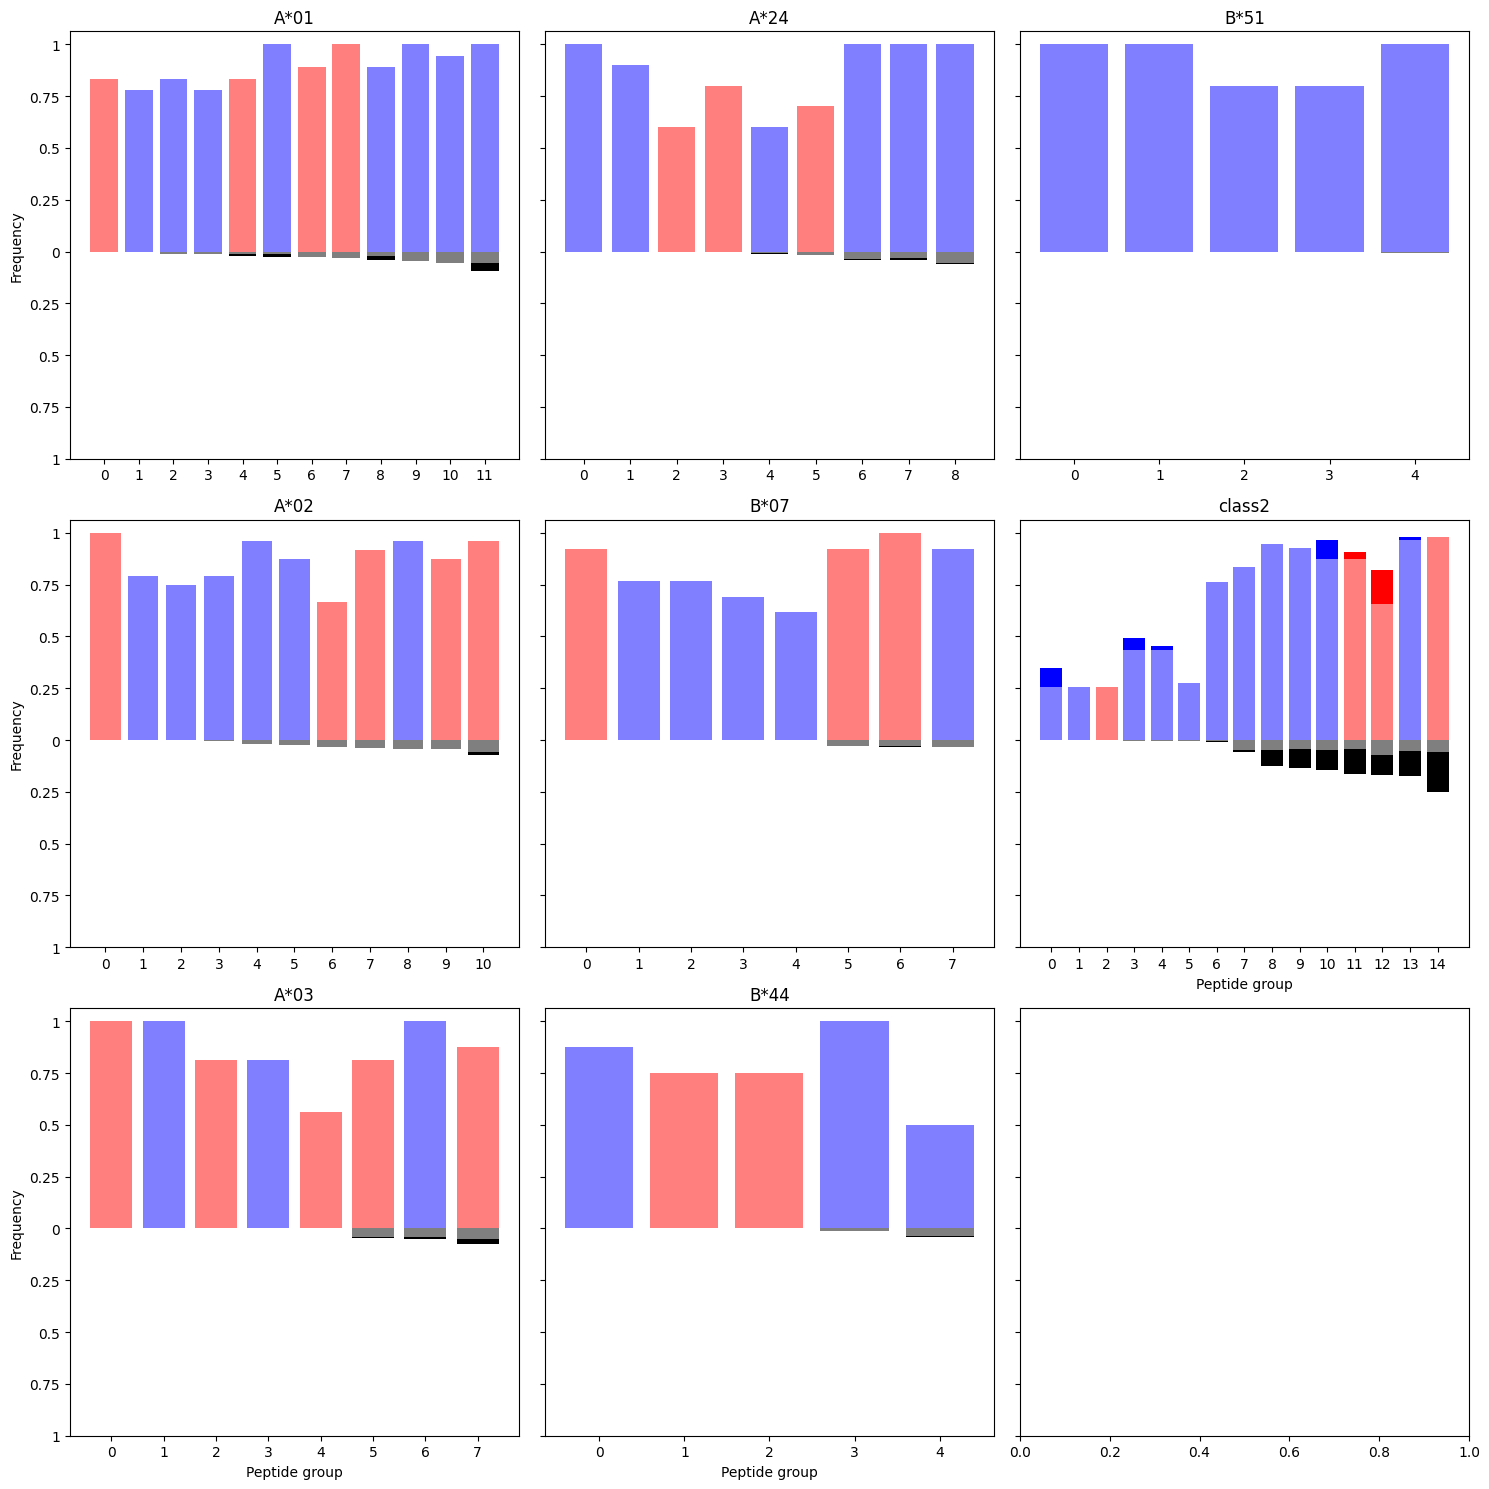

In [82]:
fig, axis = plt.subplots(3,3, figsize=(15,15), sharey=True)
plot_peptides(frequencyA01_df, A_01, axis[0,0])
axis[0,0].set_title('A*01')
axis[0,0].set_ylabel('Frequency')
plot_peptides(frequencyA02_df, A_02, axis[1,0])
axis[1,0].set_title('A*02')
axis[1,0].set_ylabel('Frequency')
plot_peptides(frequencyA03_df, A_03, axis[2,0])
axis[2,0].set_title('A*03')
axis[2,0].set_ylabel('Frequency')
axis[2,0].set_xlabel('Peptide group')
plot_peptides(frequencyA24_df, A_24, axis[0,1])
axis[0,1].set_title('A*24')
plot_peptides(frequencyB07_df, B_07, axis[1,1])
axis[1,1].set_title('B*07')
plot_peptides(frequencyB44_df, B_44, axis[2,1])
axis[2,1].set_xlabel('Peptide group')
axis[2,1].set_title('B*44')
axis[0,2].set_title('B*51')
plot_peptides(frequencyB51_df, B_51, axis[0,2])
plot_peptides(frequency2_df, class2, axis[1,2])
axis[1,2].set_xlabel('Peptide group')
axis[1,2].set_title('class2')
axis[1,2].set_yticks([-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1],[1,0.75,0.5,0.25,0,0.25,0.5,0.75,1])
plt.tight_layout()
plt.savefig('figures/immunogenicity.svg')

In [75]:
peptides_df = pd.read_csv('class1_peptides.csv', index_col=[0])
peptides_df = peptides_df[peptides_df['sample'].map(typing_dict).str.contains('A*24:02', regex=False)|(~peptides_df['sample'].str.contains('Pro', regex=False))]
all_reference = len(peptides_df[peptides_df['sample'].apply(lambda cell: info_dict[cell] =='benign' if cell in info_dict else True)]['sample'].unique())
all_prostate = len(peptides_df[peptides_df['sample'].apply(lambda cell: info_dict[cell] =='malignant' if cell in info_dict else False)]['sample'].unique())

In [76]:
all_reference

283

Identify class 2 candidates

In [ ]:
frequency2_df = compute_frequencies('class2_epitopes.csv', 'class2_peptides.csv', '')

In [ ]:
def candidate_region_epicore(df, axis, malignant_threshold, benign_threshold, original=False):
    '''Plot the candidate region of a dataset on consensus sequence level.

    Args:
        df: A dataframe containing the peptide level and consensus level frequencies.
        axis: The axis of a matplotlib plot.
        malignant_threshold: The malignant cutoff value for the candidate region.
        benign_threshold: The benign cutoff value for the candidate region.
        original: Boolean indicating if the order of the candidates on peptide level should be kept
    '''

    df = df.groupby(['whole_epitopes']).agg({'prostate_frequency_epicore':'first', 'reference_frequency_epicore':'first', 'prostate_frequency':'max', 'reference_frequency':'max'})
    df['ratio'] = (df['reference_frequency_epicore'] + 0.000001) / (df['prostate_frequency_epicore'] + 0.000001)
    df = df.sort_values('ratio')
    df = df[(df['reference_frequency_epicore']<=benign_threshold)&(df['prostate_frequency_epicore']>=malignant_threshold)]
    if original:
        df = df.sort_values(['prostate_frequency', 'reference_frequency'], ascending=[False, True])
    axis.bar([i for i in range(len(df))], df['prostate_frequency_epicore'], color='red', label='epicore prostate')
    axis.bar([i for i in range(len(df))], df['prostate_frequency'], color='white')
    axis.bar([i for i in range(len(df))], df['prostate_frequency'], color='red', alpha=0.4, label='peptide prostate')
    if max(df['reference_frequency_epicore']) > 0:
        axis.bar([i for i in range(len(df))], -df['reference_frequency_epicore'], color='black', label='epicore reference')
    if max(df['reference_frequency']) > 0:
        axis.bar([i for i in range(len(df))], -df['reference_frequency'], color='white')
        axis.bar([i for i in range(len(df))], -df['reference_frequency'], color='black', alpha=0.4, label='peptide reference')
    axis.legend(fontsize=8)
    axis.set_xticks([i for i in range(0,len(df), 5)])
    axis.set_xlabel('Peptide group', fontsize=10)
    axis.set_ylabel('Frequency', fontsize=10)

In [ ]:
def det_region(df, benign_threshold, malignant_threshold):
    df = df.groupby(['whole_epitopes']).agg({'prostate_frequency_epicore':'first', 'reference_frequency_epicore':'first', 'prostate_frequency':'max', 'reference_frequency':'max'})
    df['ratio'] = (df['reference_frequency_epicore'] + 0.000001) / (df['prostate_frequency_epicore'] + 0.000001)
    df = df.sort_values('ratio')
    df = df[(df['reference_frequency_epicore']<=benign_threshold)&(df['prostate_frequency_epicore']>=malignant_threshold)]
    return df


In [ ]:
def id_rank_increase(df):
    # identify rank on peptide level
    df = df.sort_values(['prostate_frequency', 'reference_frequency'], ascending=[False, True])
    df['prev_malignant'] = df['prostate_frequency'].shift(-1)
    df['rank'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['prostate_frequency'] else 0, axis=1)
    df['rank'] = df['rank'].cumsum()
    df['rank'] = df['rank'].shift(1)
    df.at[df.index[0],'rank'] = 0
    df = df.sort_values('ratio')
    df = df.sort_values(['prostate_frequency_epicore', 'reference_frequency_epicore'], ascending=[False, True])

    # identify rank on peptide group level
    df['prev_malignant'] = df['prostate_frequency_epicore'].shift(-1)
    df['rank_epicore'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['prostate_frequency_epicore'] else 0, axis=1)
    df['rank_epicore'] = df['rank_epicore'].cumsum()
    df['rank_epicore'] = df['rank_epicore'].shift(1)

    # identify how many candidates have higher rank due to epicore
    df.at[df.index[0],'rank_epicore'] = 0
    print(f"{len(df[df['rank']>df['rank_epicore']])} peptide groups have higher prioritization due to epicore.")

In [ ]:
candidates1_df = det_region(frequency2_df, 0, 0.2)
candidates2_df = det_region(frequency2_df, 0.01, 0.3)
candidates3_df = det_region(frequency2_df, 0.05, 0.4)
candidates4_df = det_region(frequency2_df, 0.1, 0.5)

In [ ]:
print(f"There are {len(candidates1_df)} candidates for malignant frequency >=20% and benign frequency <=0.5%")
print(f"There are {len(candidates2_df)} candidates for malignant frequency >=30% and benign frequency <=1%")
print(f"There are {len(candidates3_df)} candidates for malignant frequency >=40% and benign frequency <=5%")
print(f"There are {len(candidates4_df)} candidates for malignant frequency >=50% and benign frequency <=10%")

There are 9 candidates for malignant frequency >=20% and benign frequency <=0.5%
There are 8 candidates for malignant frequency >=30% and benign frequency <=1%
There are 24 candidates for malignant frequency >=40% and benign frequency <=5%
There are 65 candidates for malignant frequency >=50% and benign frequency <=10%


In [ ]:
id_rank_increase(candidates1_df)
id_rank_increase(candidates2_df)
id_rank_increase(candidates3_df)
id_rank_increase(candidates4_df)

1 peptide groups have higher prioritization due to epicore.
3 peptide groups have higher prioritization due to epicore.
8 peptide groups have higher prioritization due to epicore.
48 peptide groups have higher prioritization due to epicore.


In [ ]:
print(f"There are {len(candidates1_df[candidates1_df['prostate_frequency']>=0.2])} candidates for malignant frequency >=20% and benign frequency <=0.5% already candidates on peptide level")
print(f"There are {len(candidates2_df[candidates2_df['prostate_frequency']>=0.3])} candidates for malignant frequency >=30% and benign frequency <=1% already candidates on peptide level")
print(f"There are {len(candidates3_df[candidates3_df['prostate_frequency']>=0.4])} candidates for malignant frequency >=40% and benign frequency <=5% already candidates on peptide level")
print(f"There are {len(candidates4_df[candidates4_df['prostate_frequency']>=0.5])} candidates for malignant frequency >=50% and benign frequency <=10% already candidates on peptide level")

There are 7 candidates for malignant frequency >=20% and benign frequency <=0.5% already candidates on peptide level
There are 6 candidates for malignant frequency >=30% and benign frequency <=1% already candidates on peptide level
There are 22 candidates for malignant frequency >=40% and benign frequency <=5% already candidates on peptide level
There are 58 candidates for malignant frequency >=50% and benign frequency <=10% already candidates on peptide level


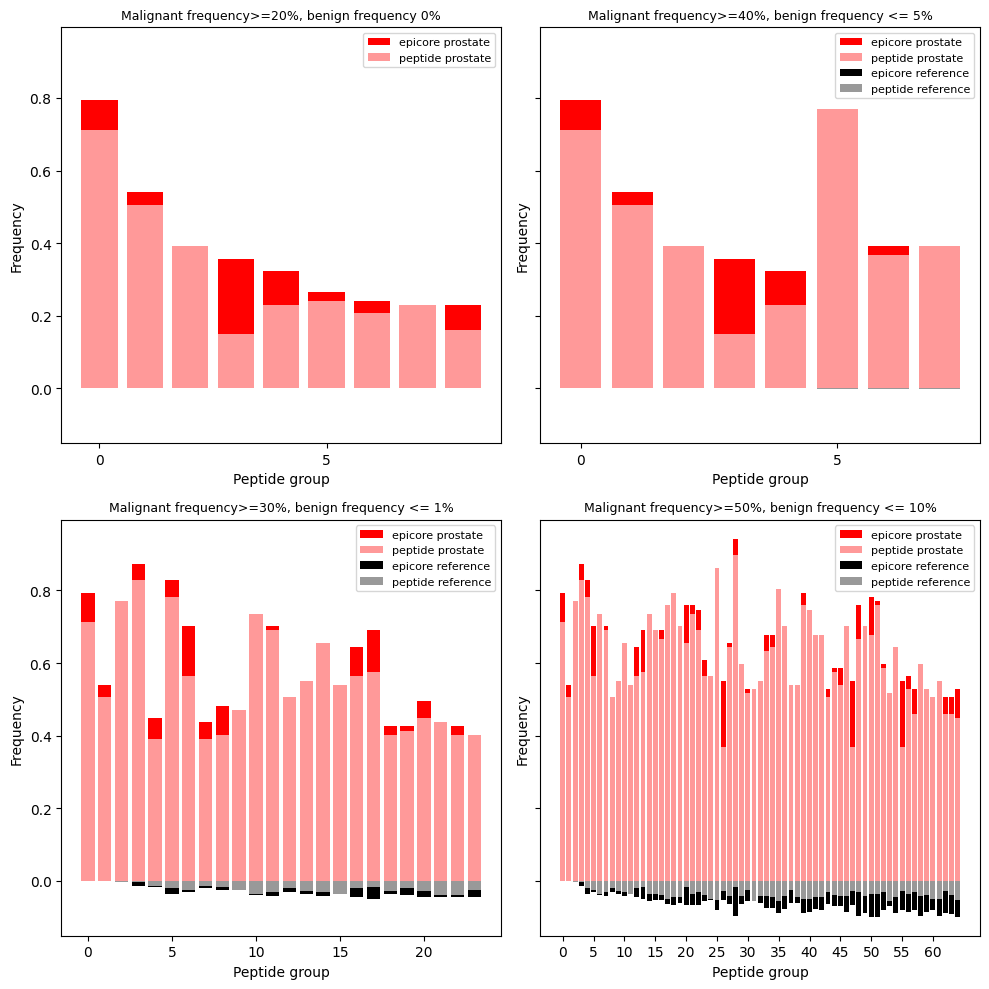

In [ ]:

fig, axis = plt.subplots(2,2, figsize=(10,10), sharey=True)
axis[0,0].set_title('Malignant frequency>=20%, benign frequency 0%', fontdict={'fontsize':9})
candidate_region_epicore(frequency2_df, axis[0,0], 0.2, 0)
axis[1,0].set_title('Malignant frequency>=30%, benign frequency <= 1%', fontdict={'fontsize':9})
candidate_region_epicore(frequency2_df, axis[0,1], 0.3, 0.01)
axis[0,1].set_title('Malignant frequency>=40%, benign frequency <= 5%', fontdict={'fontsize':9})
candidate_region_epicore(frequency2_df, axis[1,0], 0.4, 0.05)
axis[1,1].set_title('Malignant frequency>=50%, benign frequency <= 10%', fontdict={'fontsize':9})
candidate_region_epicore(frequency2_df, axis[1,1], 0.5, 0.1)
plt.tight_layout()
plt.savefig('figures/ProT_candidates2.svg')

# Identify candidates

#### Class1

In [ ]:
def id_frequency_gain(epitopes_csv, peptides_csv, allotype, benign_entire):

    peptides_df = pd.read_csv(peptides_csv)
    if allotype != '':
        if benign_entire:
            peptides_df = peptides_df[((~peptides_df['sample'].str.contains('Pro', regex=False))&(~peptides_df['biological_material_name'].str.contains('PROSTATE', regex=False, na=False)))|(peptides_df['HLA Typing'].str.contains(allotype,regex=False))]
        else:
            peptides_df = peptides_df[(~peptides_df['HLA Typing'].isnull())&(peptides_df['HLA Typing'].str.contains(allotype, regex=False))]
    all_prostate = len(peptides_df[(peptides_df['biological_material_name'].isnull())|(peptides_df['biological_material_name']=='PROSTATE')].drop_duplicates(['sample','biological_material_name']))
    all_reference = len(peptides_df.drop_duplicates(['sample','biological_material_name'])) - all_prostate
    peptides_df['sample_tissue'] = peptides_df['sample'] + peptides_df['biological_material_name']
    peptides_df = peptides_df[['sample_tissue','sequence']]
    peptides_df = peptides_df.groupby('sequence').agg({'sample_tissue':list}).reset_index()
    peptides_df['prostate_frequency'] = peptides_df['sample_tissue'].apply(lambda tissue: len([t for t in tissue if ((type(t)==float)or('PROSTATE' in t))])/all_prostate)
    peptides_df['reference_frequency'] = peptides_df['sample_tissue'].apply(lambda tissue: len([t for t in tissue if (type(t)!=float) and ('PROSTATE' not in t)])/all_reference)

    epicore_df = pd.read_csv(epitopes_csv, index_col=[0])
    epicore_df['grouped_peptides_condition'] = epicore_df['grouped_peptides_condition'].apply(lambda condition: ast.literal_eval(condition))
    epicore_df['grouped_peptides_sample'] = epicore_df['grouped_peptides_sample'].apply(lambda sample: ast.literal_eval(sample))
    epicore_df['grouped_peptides_sequence'] = epicore_df['grouped_peptides_sequence'].apply(lambda sequence: ast.literal_eval(sequence))
    epicore_df = epicore_df.explode(['grouped_peptides_sequence', 'grouped_peptides_sample','grouped_peptides_condition'])
    if benign_entire:
        epicore_df = epicore_df[((~epicore_df['grouped_peptides_sample'].str.contains('Pro', regex=False))&(~epicore_df['grouped_peptides_condition'].str.contains('PROSTATE', regex=False)))|(epicore_df['grouped_peptides_condition'].str.contains(allotype, regex=False))]
    else:
        epicore_df = epicore_df[epicore_df['grouped_peptides_condition'].str.contains(allotype, regex=False)]
    epicore_df = pd.merge(epicore_df, peptides_df, left_on='grouped_peptides_sequence', right_on='sequence', how='left')
    epicore_df = epicore_df.drop_duplicates(['sequence', 'grouped_peptides_condition','grouped_peptides_sample','whole_epitopes'])
    epicore_df = epicore_df.groupby('whole_epitopes').agg({'prostate_frequency':'max', 'reference_frequency':'max','grouped_peptides_condition':list, 'grouped_peptides_sample':list})
    epicore_df['grouped_sample_tissue'] = epicore_df.apply(lambda row: [sample+'#'+tissue for sample, tissue in zip(row['grouped_peptides_sample'], row['grouped_peptides_condition'])], axis=1)
    epicore_df['prostate_frequency_epicore'] = epicore_df['grouped_sample_tissue'].apply(lambda tissue: len(set([t for t in tissue if t.split('~')[1] in ['PROSTATE','nan']]))/all_prostate)
    epicore_df['reference_frequency_epicore'] = epicore_df['grouped_sample_tissue'].apply(lambda tissue: len(set([t for t in tissue if t.split('~')[1] not in ['PROSTATE','nan']]))/all_reference)

    return epicore_df

def plot_candidates(epicore_df, ref_freq_pep, diseas_fre_pep, ref_freq_epi, diseas_fre_epi, ref_threshold, disease_threshold,axis):

    candidates_df = epicore_df[(epicore_df[ref_freq_epi]<=ref_threshold)&(epicore_df[diseas_fre_epi]>=disease_threshold)].copy()
    candidates_df.loc[:,'ratio'] = (candidates_df[ref_freq_epi] + 0.000001) / (candidates_df[diseas_fre_epi] + 0.000001)
    candidates_df = candidates_df.sort_values('ratio')
    candidates_df = candidates_df.head(50)
    x_values = [i for i in range(len(candidates_df))]
    
    # plot malignant frequency
    axis.bar(x_values,candidates_df[diseas_fre_epi].to_list(),width=0.8, color='red', label='epicore prostate')
    axis.bar(x_values,candidates_df[diseas_fre_pep].to_list(),width=0.8, color='white')
    axis.bar(x_values,candidates_df[diseas_fre_pep].to_list(),alpha=0.4,width=0.8, color='red', label='peptide prostate')

    # plot benign frequency
    axis.bar(x_values,[-c for c in candidates_df[ref_freq_epi].to_list()],color='black',width=0.8, label='epicore reference')
    axis.bar(x_values,[-c for c in candidates_df[ref_freq_pep].to_list()],color='white',width=0.8)
    axis.bar(x_values,[-c for c in candidates_df[ref_freq_pep].to_list()],color='black',label='peptide reference',alpha=0.4,width=0.8)

    return axis

/tmp/ipykernel_1184066/2449883021.py:3: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv)
/tmp/ipykernel_1184066/2449883021.py:28: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  epicore_df = epicore_df.groupby('whole_epitopes').agg({'prostate_frequency':max, 'reference_frequency':max,'grouped_peptides_condition':list, 'grouped_peptides_sample':list})
/tmp/ipykernel_1184066/2449883021.py:28: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  epicore_df = epicore_df.groupby('whole_epitopes').agg({'prostate_frequency':max, 'reference_f

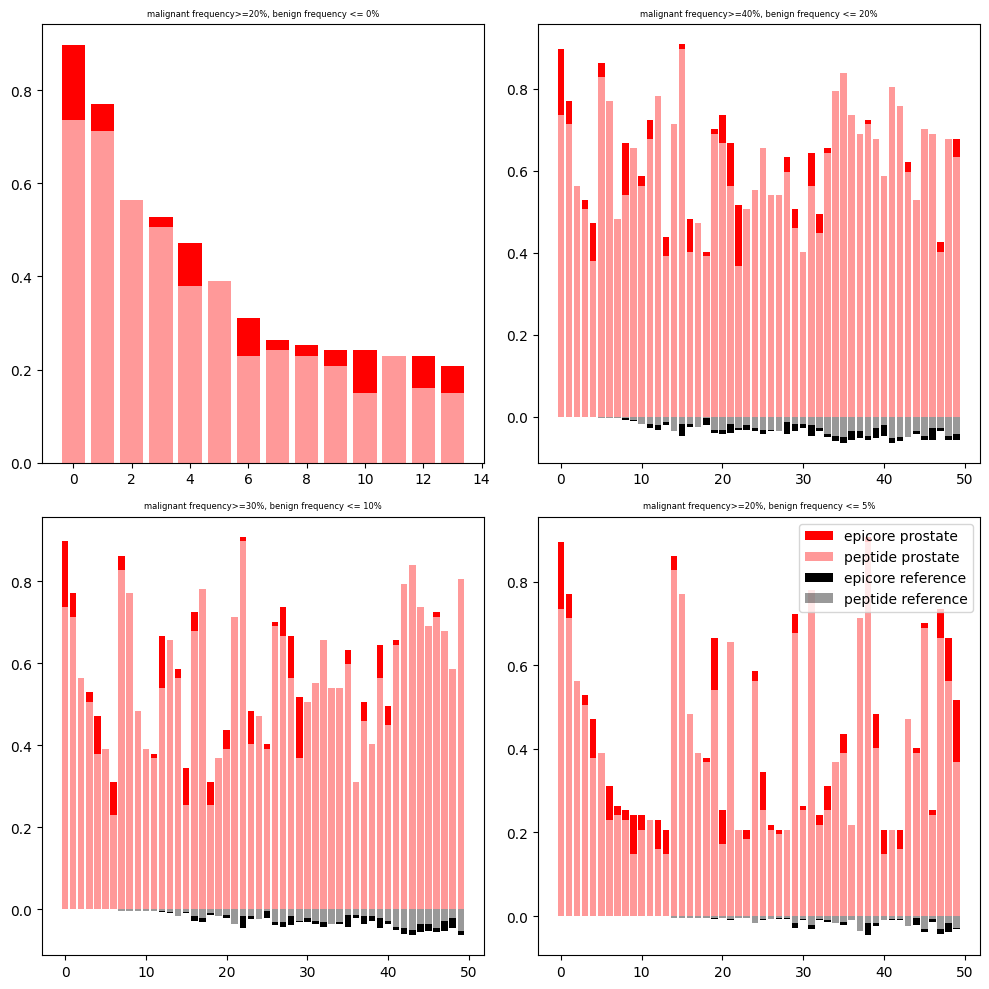

In [ ]:
fig, axis = plt.subplots(2,2, figsize=(10,10))
epicore_df = id_frequency_gain('class2_0802/epitopes.csv', 'class2_peptides.csv', '', True)
axis[0,0].set_title('malignant frequency>=20%, benign frequency <= 0%', fontdict={'fontsize':6})
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[0,0])
axis[1,0].set_title('malignant frequency>=30%, benign frequency <= 10%', fontdict={'fontsize':6})
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.1, 0.3, axis[1,0])
axis[0,1].set_title('malignant frequency>=40%, benign frequency <= 20%', fontdict={'fontsize':6})
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.2, 0.4, axis[0,1])
axis[1,1].set_title('malignant frequency>=20%, benign frequency <= 5%', fontdict={'fontsize':6})
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.05, 0.2, axis[1,1])
plt.legend()
plt.tight_layout()
plt.show()

Further investigate the top candidates

In [ ]:
epicore_df = id_frequency_gain('class2_0802/epitopes.csv', 'class2_peptides.csv', '', True)

In [ ]:
# output was removed
epicore_df[(epicore_df['prostate_frequency_epicore']>0.5)&(epicore_df['reference_frequency_epicore']==0)]

#### Class 1

/tmp/ipykernel_1188047/1367642601.py:3: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv)
/tmp/ipykernel_1188047/1367642601.py:3: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv)
/tmp/ipykernel_1188047/1367642601.py:3: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv)
/tmp/ipykernel_1188047/1367642601.py:3: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv)
/tmp/ipykernel_1188047/1367642601.py:3: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv)
/tmp/ipykernel_1188047/1367642601.py:3: DtypeWarning: Columns (6,7) have mixed t

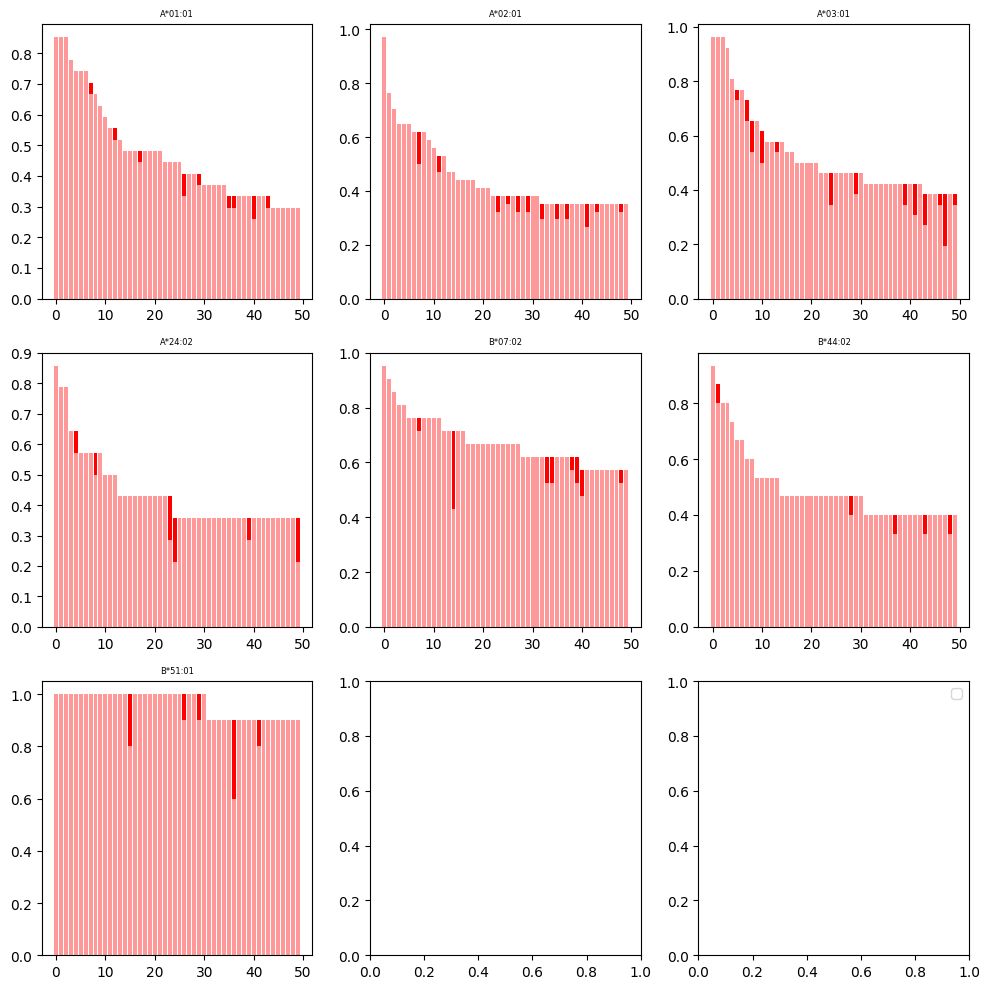

In [ ]:
fig, axis = plt.subplots(3,3, figsize=(10,10))
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'A*01:01', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[0,0])
axis[0,0].set_title('A*01:01', fontdict={'fontsize':6})
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'A*02:01', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[0,1])
axis[0,1].set_title('A*02:01', fontdict={'fontsize':6})
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'A*03:01', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[0,2])
axis[0,2].set_title('A*03:01', fontdict={'fontsize':6})
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'A*24:02', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[1,0])
axis[1,0].set_title('A*24:02', fontdict={'fontsize':6})
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'B*07:02', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[1,1])
axis[1,1].set_title('B*07:02', fontdict={'fontsize':6})
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'B*44:02', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[1,2])
axis[1,2].set_title('B*44:02', fontdict={'fontsize':6})
epicore_df = id_frequency_gain('class1_0802/epitopes.csv', 'class1_peptides.csv', 'B*51:01', False)
plot_candidates(epicore_df.reset_index(), 'reference_frequency', 'prostate_frequency', 'reference_frequency_epicore', 'prostate_frequency_epicore', 0.0, 0.2, axis[2,0])
axis[2,0].set_title('B*51:01', fontdict={'fontsize':6})
plt.legend()
plt.tight_layout()
plt.show()